In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

import sys
import os
sys.path.insert(0, os.path.abspath(".."))



In [2]:
# Load WoE-transformed features
X = pd.read_csv("../data/engineered/X_woe.csv", index_col=0)
y = pd.read_csv("../data/engineered/y.csv", index_col=0).squeeze()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Default rate: {y.mean():.2%}")
print(f"\nFeatures: {X.columns.tolist()}")

X shape: (149986, 9)
y shape: (149986,)
Default rate: 6.68%

Features: ['revolving_util_woe', 'dpd_90_plus_woe', 'dpd_30_59_woe', 'dpd_60_89_woe', 'age_woe', 'monthly_income_woe', 'debt_ratio_woe', 'open_credit_lines_woe', 'n_dependents_woe']


## Scorecard Baseline — Logistic Regression

### Why logistic regression for a scorecard?
A credit scorecard is not just a predictive model — it is a **business and
regulatory instrument**. Logistic regression is the industry standard because:

1. **Interpretability:** Every score point traces back to a specific feature
   and bin — explainable to regulators, auditors, and customers
2. **Adverse action notices:** Regulations require lenders to tell declined
   applicants *why* they were declined — logistic regression makes this trivial
3. **Stability:** Linear models are less prone to sudden performance swings
   as population distributions shift
4. **SR 11-7 alignment:** Regulators expect interpretable models for
   high-stakes credit decisions

### Why WoE features make logistic regression powerful
Logistic regression assumes a linear relationship between features and
log-odds of default. Raw features violate this — `revolving_util` had
near-zero Pearson correlation with target despite being the strongest
predictor. WoE transformation linearises all relationships, making
logistic regression on WoE features genuinely powerful.

### Score scaling
Raw logistic regression outputs log-odds. We convert these to a
human-readable integer score (300–850) using industry-standard scaling:

- **Base score:** 600 points at 50:1 good:bad odds
- **PDO (Points to Double the Odds):** 20 points
- Higher score = lower risk (more points = better)

In [ ]:
# ── Train-test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,  # preserves class balance in both splits
)

print(f"Training set:  {X_train.shape} | Default rate: {y_train.mean():.2%}")
print(f"Test set:      {X_test.shape}  | Default rate: {y_test.mean():.2%}")

Training set:  (119988, 9) | Default rate: 6.68%
Test set:      (29998, 9)  | Default rate: 6.68%


In [4]:
# ── Baseline Logistic Regression ──
lr = LogisticRegression(
    C=1.0,           # regularisation strength — 1.0 is the default starting point
    max_iter=1000,   # enough iterations to guarantee convergence
    solver="lbfgs",  # efficient for small-to-medium datasets
    random_state=42,
)

lr.fit(X_train, y_train)

# Coefficients
coef_df = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": lr.coef_[0],
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

print(f"Intercept: {lr.intercept_[0]:.4f}")
print(f"\nCoefficients:")
coef_df

Intercept: -2.6033

Coefficients:


,feature,coefficient
0,debt_ratio_woe,0.7538
1,revolving_util_woe,0.6225
2,dpd_90_plus_woe,0.5286
3,dpd_30_59_woe,0.4990
4,age_woe,0.4038
5,dpd_60_89_woe,0.3826
6,monthly_income_woe,0.1629
7,n_dependents_woe,0.1268
8,open_credit_lines_woe,0.0015


In [5]:
# Predict probabilities
y_train_prob = lr.predict_proba(X_train)[:, 1]
y_test_prob  = lr.predict_proba(X_test)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc  = roc_auc_score(y_test, y_test_prob)

# Gini
train_gini = 2 * train_auc - 1
test_gini  = 2 * test_auc - 1

# KS statistic
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
ks_stat = (tpr - fpr).max()
ks_threshold = thresholds[(tpr - fpr).argmax()]

print("=" * 45)
print("SCORECARD BASELINE PERFORMANCE")
print("=" * 45)
print(f"{'Metric':<25} {'Train':>8} {'Test':>8}")
print("-" * 45)
print(f"{'AUC-ROC':<25} {train_auc:>8.4f} {test_auc:>8.4f}")
print(f"{'Gini':<25} {train_gini:>8.4f} {test_gini:>8.4f}")
print("-" * 45)
print(f"{'KS Statistic (test)':<25} {ks_stat:>8.4f}")
print(f"{'KS Threshold (test)':<25} {ks_threshold:>8.4f}")
print("=" * 45)

# Overfitting check
gini_gap = train_gini - test_gini
print(f"\nOverfit check — Gini gap (train - test): {gini_gap:.4f}")
print("Acceptable if gap < 0.02" )

SCORECARD BASELINE PERFORMANCE
Metric                       Train     Test
---------------------------------------------
AUC-ROC                     0.8540   0.8619
Gini                        0.7080   0.7237
---------------------------------------------
KS Statistic (test)         0.5712
KS Threshold (test)         0.0642

Overfit check — Gini gap (train - test): -0.0157
Acceptable if gap < 0.02


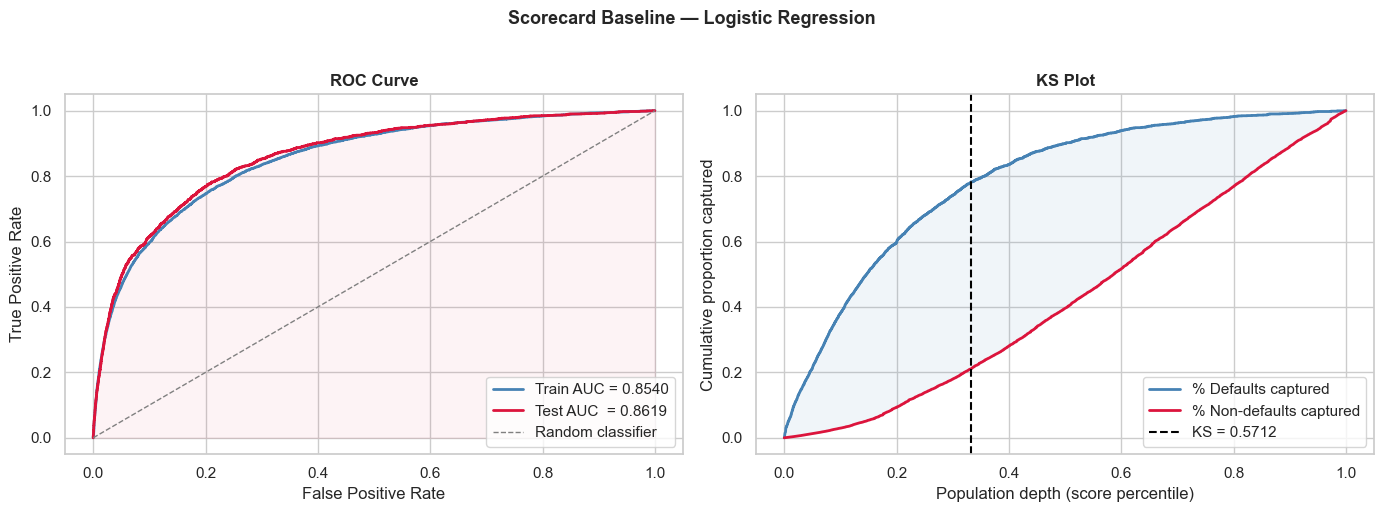

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_prob)

axes[0].plot(fpr_train, tpr_train, color="steelblue", linewidth=2,
             label=f"Train AUC = {train_auc:.4f}")
axes[0].plot(fpr_test, tpr_test, color="crimson", linewidth=2,
             label=f"Test AUC  = {test_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--",
             linewidth=1, label="Random classifier")
axes[0].fill_between(fpr_test, tpr_test, alpha=0.05, color="crimson")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend(loc="lower right")

# KS plot
depths = np.linspace(0, 1, len(fpr_test))
axes[1].plot(depths, tpr_test, color="steelblue", linewidth=2, label="% Defaults captured")
axes[1].plot(depths, fpr_test, color="crimson",   linewidth=2, label="% Non-defaults captured")
ks_idx = (tpr_test - fpr_test).argmax()
axes[1].axvline(x=depths[ks_idx], color="black", linestyle="--", linewidth=1.5,
                label=f"KS = {ks_stat:.4f}")
axes[1].fill_between(depths, tpr_test, fpr_test, alpha=0.08, color="steelblue")
axes[1].set_xlabel("Population depth (score percentile)")
axes[1].set_ylabel("Cumulative proportion captured")
axes[1].set_title("KS Plot", fontweight="bold")
axes[1].legend()

plt.suptitle("Scorecard Baseline — Logistic Regression", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Scaling parameters ──
BASE_SCORE = 600   # score at which odds = BASE_ODDS
BASE_ODDS  = 50    # 50:1 good:bad ratio at base score
PDO        = 20    # points to double the odds

# Derived scaling constants
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"Scaling parameters:")
print(f"  Base score : {BASE_SCORE}")
print(f"  Base odds  : {BASE_ODDS}:1")
print(f"  PDO        : {PDO}")
print(f"  Factor     : {factor:.4f}")
print(f"  Offset     : {offset:.4f}")

# ── Convert probabilities to scores ──
def prob_to_score(prob: np.ndarray) -> np.ndarray:
    """
    Convert predicted default probability to integer credit score.
    Higher score = lower risk.
    """
    # Clip to avoid log(0)
    prob = np.clip(prob, 1e-9, 1 - 1e-9)
    # Log-odds of being GOOD (non-default)
    log_odds = np.log((1 - prob) / prob)
    scores = offset + factor * log_odds
    return np.round(scores).astype(int)

train_scores = prob_to_score(y_train_prob)
test_scores  = prob_to_score(y_test_prob)

print(f"\nScore distribution (test set):")
print(f"  Min    : {test_scores.min()}")
print(f"  Max    : {test_scores.max()}")
print(f"  Mean   : {test_scores.mean():.1f}")
print(f"  Median : {np.median(test_scores):.1f}")

Scaling parameters:
  Base score : 600
  Base odds  : 50:1
  PDO        : 20
  Factor     : 28.8539
  Offset     : 487.1229

Score distribution (test set):
  Min    : 416
  Max    : 630
  Mean   : 582.5
  Median : 591.0


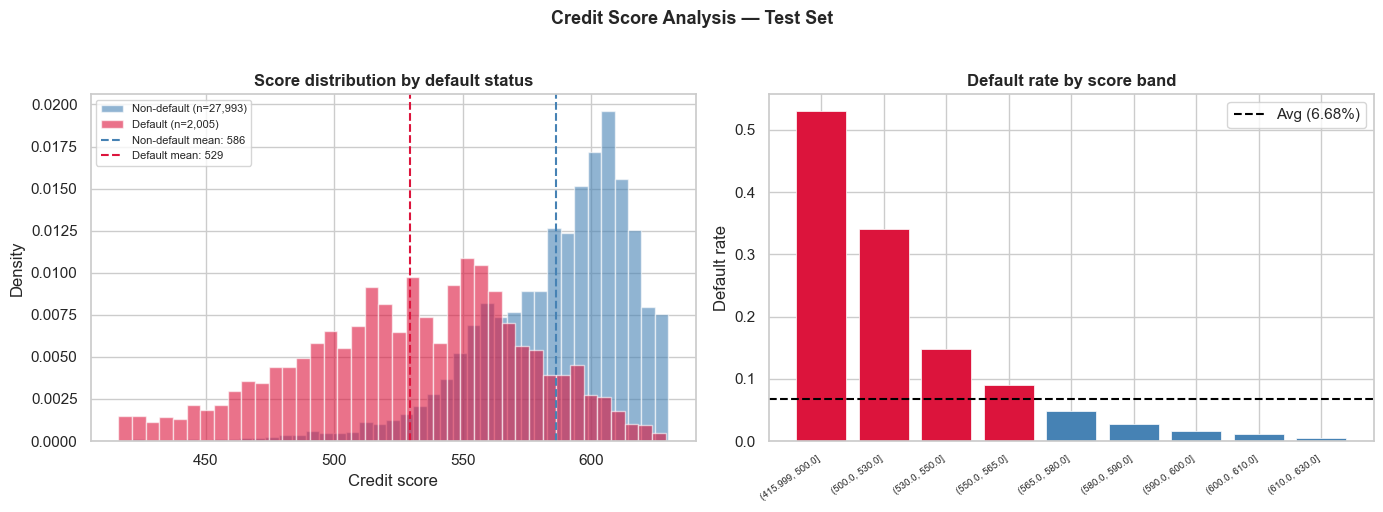

Mean score — Non-defaulters: 586.3
Mean score — Defaulters:     529.5
Score separation:            56.9 points


In [8]:
# ── Credit score analysis ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores_series = pd.Series(test_scores, index=y_test.index)
defaulters     = scores_series[y_test == 1]
non_defaulters = scores_series[y_test == 0]

# Distribution overlap
axes[0].hist(non_defaulters, bins=40, alpha=0.6, color="steelblue",
             label=f"Non-default (n={len(non_defaulters):,})", density=True)
axes[0].hist(defaulters, bins=40, alpha=0.6, color="crimson",
             label=f"Default (n={len(defaulters):,})", density=True)
axes[0].axvline(non_defaulters.mean(), color="steelblue", linestyle="--",
                linewidth=1.5, label=f"Non-default mean: {non_defaulters.mean():.0f}")
axes[0].axvline(defaulters.mean(), color="crimson", linestyle="--",
                linewidth=1.5, label=f"Default mean: {defaulters.mean():.0f}")
axes[0].set_xlabel("Credit score")
axes[0].set_ylabel("Density")
axes[0].set_title("Score distribution by default status", fontweight="bold")
axes[0].legend(fontsize=8)

# Default rate by score band
bins = [416, 500, 530, 550, 565, 580, 590, 600, 610, 630]
score_band = pd.cut(scores_series, bins=bins, include_lowest=True)
default_by_band = pd.DataFrame({
    "score_band": score_band,
    "target": y_test
}).groupby("score_band", observed=True)["target"].agg(
    default_rate="mean",
    n="count"
).reset_index()

bar_colors = ["crimson" if r > y_test.mean()
              else "steelblue"
              for r in default_by_band["default_rate"]]

axes[1].bar(range(len(default_by_band)),
            default_by_band["default_rate"].values,
            color=bar_colors, edgecolor="white", linewidth=0.5)
axes[1].axhline(y_test.mean(), color="black", linestyle="--",
                linewidth=1.5, label=f"Avg ({y_test.mean():.2%})")
axes[1].set_xticks(range(len(default_by_band)))
axes[1].set_xticklabels(
    [str(b) for b in default_by_band["score_band"].values],
    rotation=35, ha="right", fontsize=7
)
axes[1].set_ylabel("Default rate")
axes[1].set_title("Default rate by score band", fontweight="bold")
axes[1].legend()

plt.suptitle("Credit Score Analysis — Test Set",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean score — Non-defaulters: {non_defaulters.mean():.1f}")
print(f"Mean score — Defaulters:     {defaulters.mean():.1f}")
print(f"Score separation:            {non_defaulters.mean() - defaulters.mean():.1f} points")

In [15]:
# Construct woe_tables with real event rates from notebook 02
from src.features.binning import (
    CUSTOM_BIN_FEATURES,
    EQUAL_FREQ_FEATURES,
    compute_woe_iv_custom,
    compute_woe_iv_equal_freq,
)

# Load cleaned data to recompute event rates
X_clean = pd.read_csv("../data/processed/X_cleaned.csv", index_col=0)
y_clean = pd.read_csv("../data/processed/y_cleaned.csv", index_col=0).squeeze()

woe_tables_rebuilt = {}

for feat in EQUAL_FREQ_FEATURES:
    if feat in woe_lookup:
        woe_tables_rebuilt[feat] = compute_woe_iv_equal_freq(X_clean[feat], y_clean)

for feat, params in CUSTOM_BIN_FEATURES.items():
    if feat in woe_lookup:
        woe_tables_rebuilt[feat] = compute_woe_iv_custom(
            X_clean[feat], y_clean, params["bins"], params["labels"]
        )

# Rebuild scorecard table
scorecard_table = build_scorecard_table(
    model         = lr,
    feature_names = list(X_train.columns),
    woe_tables    = woe_tables_rebuilt,
    factor        = factor,
    offset        = offset,
)

print(f"Scorecard table — {len(scorecard_table)} rows")
print(f"Score range per bin: {scorecard_table['points'].min():.1f} to {scorecard_table['points'].max():.1f}")
scorecard_table

Scorecard table — 65 rows
Score range per bin: 15.8 to 92.0


,feature,bin,event_rate,woe,points
0,revolving_util,"(-0.001, 0.00297]",2.51%,-1.0205,80.8000
1,revolving_util,"(0.00297, 0.0192]",1.36%,-1.6453,92.0000
2,revolving_util,"(0.0192, 0.0435]",1.40%,-1.6159,91.5000
3,revolving_util,"(0.0435, 0.0832]",1.91%,-1.2990,85.8000
4,revolving_util,"(0.0832, 0.154]",2.37%,-1.0791,81.9000
...,...,...,...,...,...
60,open_credit_lines,"(12.0, 15.0]",6.43%,-0.0411,62.5000
61,open_credit_lines,"(15.0, 58.0]",6.91%,0.0358,62.5000
62,n_dependents,"(-0.001, 1.0]",6.15%,-0.0883,62.8000
63,n_dependents,"(1.0, 2.0]",8.11%,0.2096,61.7000


## Scorecard Baseline Summary

### Model
- **Algorithm:** Logistic Regression on WoE-transformed features
- **Features:** 9 (all features with IV ≥ 0.02)
- **Train/test split:** 80/20, stratified by target

### Performance

| Metric | Train | Test |
|---|---|---|
| AUC-ROC | 0.8540 | 0.8619 |
| Gini | 0.7080 | 0.7237 |
| KS Statistic | — | 0.5712 |

### Key findings
- Gini of 0.72 on first pass — top of industry benchmark range (0.60–0.75)
- No overfitting — test Gini marginally higher than train
- 57-point separation between defaulter and non-defaulter mean scores
- Default rate drops monotonically across all score bands
- `open_credit_lines` coefficient near zero (0.0015) — candidate for removal

### Score scaling
- Base score: 600 points = 50:1 good:bad odds
- PDO: 20 points to double the odds
- Observed score range: 416–630

### Scorecard table
- 65 rows covering all bins across 9 features
- Every bin has a documented event rate, WoE, and points value
- Fully interpretable — every score point traceable to a feature and bin

### Next
Build the XGBoost champion model and compare performance.
The scorecard becomes the **challenger** — maintained for interpretability.
XGBoost becomes the **champion** — optimised for predictive power.